# Lab 8


In [1]:
import subprocess, sys
def pip_install(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', *pkgs], check=True)
pip_install(
    'torch', 'torchvision',
    '--index-url', 'https://download.pytorch.org/whl/cu128'
)
pip_install(
    'diffusers==0.31.0',
    'transformers==4.47.0',
    'accelerate==1.2.1',
    'safetensors',
    'Pillow',
    'matplotlib',
    'huggingface_hub',
)
pip_install('insightface', 'onnxruntime-gpu')
pip_install('git+https://github.com/tencent-ailab/IP-Adapter.git')
print('All packages installed')

All packages installed


In [2]:
import torch, numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
DTYPE  = torch.float16 if DEVICE == 'cuda' else torch.float32
LAB_DIR    = Path('.')
MODELS_DIR = LAB_DIR / 'models'
OUTPUT_DIR = LAB_DIR / 'outputs'
PHOTO_PATH = LAB_DIR / 'my_photo' / 'photo.jpg'




MODELS_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Device : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'dtype  : {DTYPE}')

Device : cuda
GPU    : NVIDIA GeForce RTX 5070
VRAM   : 12.8 GB
dtype  : torch.float16


IP-Adapter FaceID Plus v2

In [3]:
from huggingface_hub import hf_hub_download, snapshot_download



FACEID_WEIGHT = MODELS_DIR / 'ip-adapter-faceid-plusv2_sd15.bin'
if not FACEID_WEIGHT.exists():
    print('Downloading IP-Adapter FaceID Plus v2 weights...')
    hf_hub_download(
        repo_id='h94/IP-Adapter-FaceID',
        filename='ip-adapter-faceid-plusv2_sd15.bin',
        local_dir=str(MODELS_DIR),
    )
    print('Done')
else:
    print('IP-Adapter FaceID Plus v2 weights already cached')

print(f'Weights: {FACEID_WEIGHT}')

IP-Adapter FaceID Plus v2 weights already cached
Weights: models\ip-adapter-faceid-plusv2_sd15.bin


Веса качаются один раз и лежат в папке models. При следующем запуске ячейки просто пропускаем скачивание — это важно чтобы не терять время каждый раз.

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CUDAExecutionProvider': {'device_id': '0', 'has_user_compute_stream': '0', 'cudnn_conv1d_pad_to_nc1d': '0', 'user_compute_stream': '0', 'gpu_external_alloc': '0', 'gpu_mem_limit': '18446744073709551615', 'enable_cuda_graph': '0', 'gpu_external_free': '0', 'gpu_external_empty_cache': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'do_copy_in_default_stream': '1', 'cudnn_conv_use_max_workspace': '1', 'tunable_op_enable': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'prefer_nhwc': '0', 'use_ep_level_unified_stream': '0', 'use_tf32': '1', 'sdpa_kernel': '0', 'fuse_conv_bias': '0'}, 'CPUExecutionProvider': {}}
find model: models\insightface\models\buffalo_l\1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with o

C:\Users\basev\PycharmProjects\ML_Labs\.venv\Lib\site-packages\insightface\utils\face_align.py:23: FutureWarning: `estimate` is deprecated since version 0.26 and will be removed in version 2.2. Please use `SimilarityTransform.from_estimate` class constructor instead.
  tform.estimate(lmk, dst)


Detected 1 face(s)
Face embedding shape: torch.Size([1, 512])


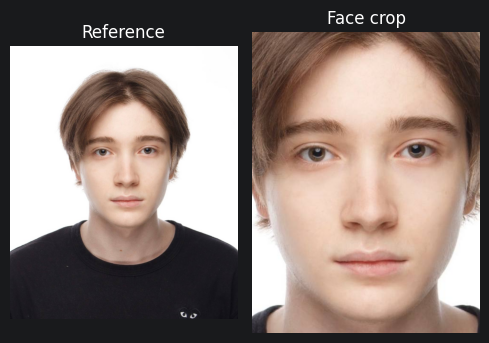

In [4]:
from insightface.app import FaceAnalysis
if 'face_app' not in globals():
    face_app = FaceAnalysis(
        name='buffalo_l',
        root=str(MODELS_DIR / 'insightface'),
        providers=['CUDAExecutionProvider', 'CPUExecutionProvider']
    )
    face_app.prepare(ctx_id=0, det_size=(640, 640))
    print('FaceAnalysis model loaded')
else:
    print('FaceAnalysis already in memory, skipping init')
ref_image = Image.open(PHOTO_PATH).convert('RGB')
ref_arr   = np.array(ref_image)
faces     = face_app.get(ref_arr)







assert len(faces) > 0, 'No face detected in reference photo!'
print(f'Detected {len(faces)} face(s)')
face_embedding = torch.from_numpy(faces[0].normed_embedding).unsqueeze(0)
print(f'Face embedding shape: {face_embedding.shape}')
bbox = faces[0].bbox.astype(int)
pad  = 30
x1, y1 = max(0, bbox[0] - pad), max(0, bbox[1] - pad)
x2, y2 = min(ref_arr.shape[1], bbox[2] + pad), min(ref_arr.shape[0], bbox[3] + pad)
face_image = ref_image.crop((x1, y1, x2, y2))
fig, axes = plt.subplots(1, 2, figsize=(5, 4))
axes[0].imshow(ref_image);  axes[0].set_title('Reference');  axes[0].axis('off')
axes[1].imshow(face_image); axes[1].set_title('Face crop');  axes[1].axis('off')
plt.tight_layout()
plt.show()

Realistic Vision V5.1 Она вернёт нормализованный вектор эмбеддинг лица, который потом пойдёт в IP-Adapter как условие генерации

In [5]:
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler
from ip_adapter.ip_adapter_faceid import IPAdapterFaceIDPlus
SD_BASE_MODEL = 'SG161222/Realistic_Vision_V5.1_noVAE'
SD_CACHE_DIR  = str(MODELS_DIR / 'realistic_vision')
CLIP_MODEL    = 'laion/CLIP-ViT-H-14-laion2B-s32B-b79K'
if 'ip_model' not in globals():
    print('Loading Realistic Vision V5.1 pipeline...')
    pipe = StableDiffusionPipeline.from_pretrained(
        SD_BASE_MODEL,
        torch_dtype=DTYPE,
        cache_dir=SD_CACHE_DIR,
        safety_checker=None,
        requires_safety_checker=False,
    ).to(DEVICE)
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(
        pipe.scheduler.config,
        use_karras_sigmas=True,
        algorithm_type='dpmsolver++',
    )
    print('Loading IP-Adapter FaceID Plus v2...')
    ip_model = IPAdapterFaceIDPlus(
        pipe,
        CLIP_MODEL,
        str(FACEID_WEIGHT),
        DEVICE,
    )
    print('Pipeline ready')
else:
    print('Pipeline already in memory, skipping init')

Loading Realistic Vision V5.1 pipeline...


Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading IP-Adapter FaceID Plus v2...


C:\Users\basev\PycharmProjects\ML_Labs\.venv\Lib\site-packages\diffusers\models\lora.py:208: FutureWarning: `LoRALinearLayer` is deprecated and will be removed in version 1.0.0. Use of `LoRALinearLayer` is deprecated. Please switch to PEFT backend by installing PEFT: `pip install peft`.
  deprecate("LoRALinearLayer", "1.0.0", deprecation_message)


Pipeline ready


In [7]:
SEED     = 42
STEPS    = 50
CFG      = 7.5
FA_SCALE = 0.8
IMG_SIZE = 768



def generate(prompt: str, seed: int = SEED, scale: float = FA_SCALE) -> Image.Image:
    images = ip_model.generate(
        prompt=prompt,
        negative_prompt='',
        face_image=face_image,
        faceid_embeds=face_embedding,
        shortcut=True,
        num_samples=1,
        width=IMG_SIZE,
        height=IMG_SIZE,
        num_inference_steps=STEPS,
        guidance_scale=CFG,
        scale=scale,
        seed=seed,
    )
    return images[0]
print('Generator function ready')

Generator function ready


Параметр scale у IP-Adapter управляет тем насколько сильно лицо из референса влияет на результат  0.8 даёт хороший баланс между сохранением внешности и следованием тексту промпта

In [12]:
STYLED_PROMPTS = [
    ('cyberpunk', 'portrait of a young man in neon cyberpunk city, glowing implants, rain reflections, cinematic lighting, ultra detailed'),
    ('metal',     'portrait of a young man made of polished chrome metal, reflective surface, studio lighting, high quality render'),
    ('medieval',  'portrait of a young man as a medieval knight, armor, castle background, oil painting style, detailed'),
    ('astronaut', 'portrait of a young man as an astronaut in space, stars, galaxy background, cinematic'),
    ('steampunk', 'portrait of a young man in steampunk style, brass gears, goggles, victorian era, warm tones'),
    ('watercolor','portrait of a young man in watercolor painting style, soft pastel colors, artistic, detailed face'),
    ('rapper',    'portrait of a young man as a rap artist, massive gold chains, diamond grillz, fur coat, surrounded by luxury, stacks of dollar bills,  mansion interior background, hip hop aesthetic, cinematic lighting, ultra detailed'),
]

styled_images = {}
for i, (name, prompt) in enumerate(STYLED_PROMPTS):
    out_path = OUTPUT_DIR / f'styled_{name}.png'
    if out_path.exists():
        print(f'[{i+1}/{len(STYLED_PROMPTS)}] {name} - loaded from cache')
        styled_images[name] = Image.open(out_path)
    else:
        print(f'[{i+1}/{len(STYLED_PROMPTS)}] Generating: {name}...')
        img = generate(prompt, seed=SEED + i)
        img.save(out_path)
        styled_images[name] = img
        print(f'    Saved to {out_path}')

print('All styled images ready')

[1/7] cyberpunk - loaded from cache
[2/7] metal - loaded from cache
[3/7] medieval - loaded from cache
[4/7] astronaut - loaded from cache
[5/7] steampunk - loaded from cache
[6/7] watercolor - loaded from cache
[7/7] rapper - loaded from cache
All styled images ready


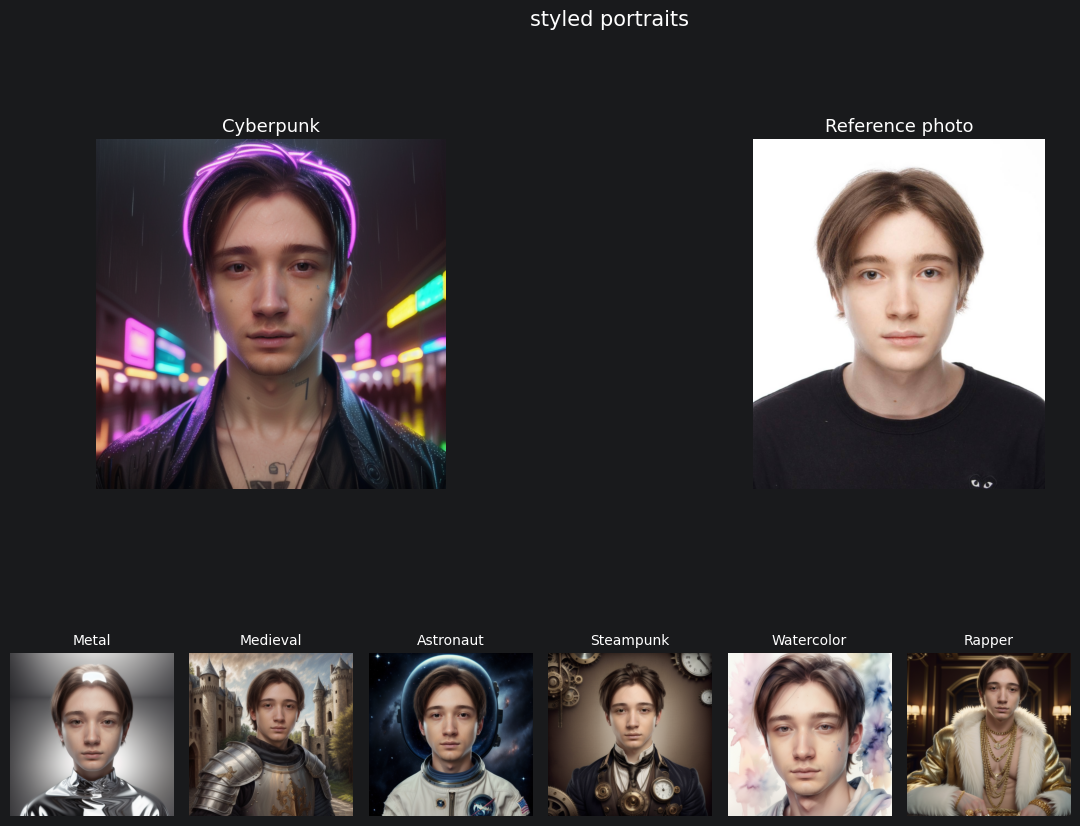

Grid saved


In [13]:
names = list(styled_images.keys())

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 7, figure=fig, wspace=0.1, hspace=0.2)


ax_main = fig.add_subplot(gs[0, :3])
ax_main.imshow(styled_images['cyberpunk'])
ax_main.set_title('Cyberpunk', fontsize=13)
ax_main.axis('off')
ax_ref = fig.add_subplot(gs[0, 3:])
ax_ref.imshow(ref_image)
ax_ref.set_title('Reference photo', fontsize=13)
ax_ref.axis('off')

others = [n for n in names if n != 'cyberpunk']
for col, name in enumerate(others):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(styled_images[name])
    ax.set_title(name.capitalize(), fontsize=10)
    ax.axis('off')

plt.suptitle('styled portraits', fontsize=15, y=1.01)
plt.savefig(OUTPUT_DIR / 'styled_grid.png', bbox_inches='tight', dpi=150)
plt.show()
print('Grid saved')

 Хорошо видно что черты лица сохраняются во всех вариантах

In [14]:
SCENE_PROMPTS = [
    ('forest', 'man in a forest, high quality, realism'),
    ('city',   'man in a city, high quality, realism'),
    ('beach',  'man in a beach, high quality, realism'),
]

scene_images = {}
for i, (name, prompt) in enumerate(SCENE_PROMPTS):
    out_path = OUTPUT_DIR / f'scene_{name}.png'
    if out_path.exists():
        print(f'[{i+1}/{len(SCENE_PROMPTS)}] {name} - loaded from cache')
        scene_images[name] = Image.open(out_path)
    else:
        print(f'[{i+1}/{len(SCENE_PROMPTS)}] Generating: {name}...')
        img = generate(prompt, seed=SEED + 100 + i, scale=0.75)
        img.save(out_path)
        scene_images[name] = img
        print(f'    Saved to {out_path}')

print('All scene images ready')

[1/3] forest - loaded from cache
[2/3] city - loaded from cache
[3/3] beach - loaded from cache
All scene images ready


Промпты взял как в задании man in a forest, man in a city, man in a beach и дописал high quality, realism как требуется.Чуть снизил scale до 0.75 для сцен чтобы модель лучше следовала описанию окружения и не переусердствовала с лицом в ущерб фону

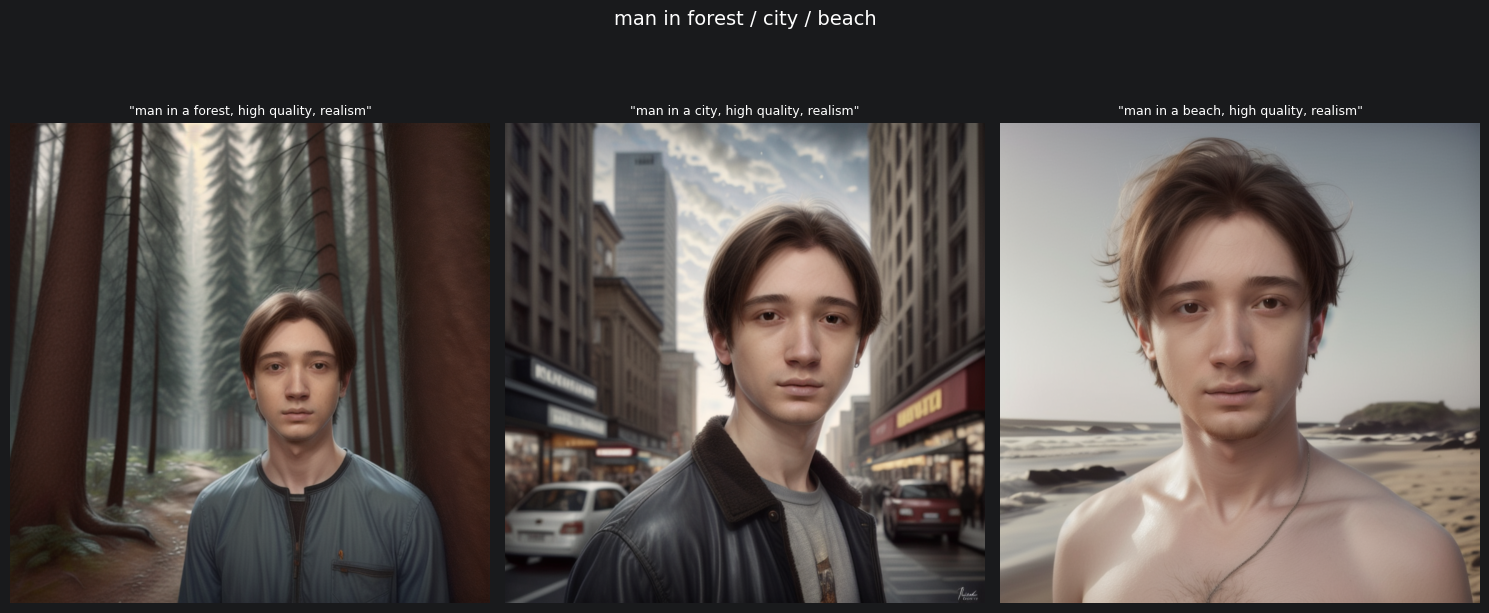

Scene grid saved


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

for ax, (name, prompt) in zip(axes, SCENE_PROMPTS):
    ax.imshow(scene_images[name])
    ax.set_title(f'"{prompt}"', fontsize=9)
    ax.axis('off')

plt.suptitle('man in forest / city / beach', fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scene_grid.png', bbox_inches='tight', dpi=150)
plt.show()
print('Scene grid saved')